# Landau Damping In An Homogeneous and Isotropic Neutrino Gas

## Huaiyu Duan (University of New Mexico)

For a homogeneous and isotropic neutrino medium, the frequency $\Omega$ and growth rate $\gamma$ of the collective oscillation modeis given by the root $s^* = \gamma - \mathrm{i}\Omega$ of equation

$$ [1 - \chi^0_0(s^*)][1 - \chi^1_1(s^*)][1 - \chi^2_2(s^*)][1 - \chi^3_3(s^*)] = 0, $$

where

$$ \chi^0_0(s) = -3 \chi^i_i(s) \int_{-\infty}^{\infty} \frac{g(\omega)\,\mathrm{d}\omega}{1 + \mathrm{i} s - \omega}
    - 2\pi \mathrm{i} g(1 + \mathrm{i} s)
    \Theta(-\mathrm{Re}(s)).
$$

Here $\omega = \pm\delta m^2 \cos(2\theta_\mathrm{v}) / 2E$ is the (effective) vacuum frequency of the neutrino and antineutrino, and $\Theta(x)$ is the Heaviside step function.

In [1]:
import numpy as np
from scipy.integrate import quad

def chi00(s, g, a=-np.inf, b=np.inf):
    "Response function defined above. The integration limits a and b should be chosen to cover the support of g(omega)."
    # Imaginary and real parts of the integrand
    int_real = lambda omega: g(omega) * (1 - s.imag - omega) / ((1 - s.imag - omega) ** 2 + s.real ** 2)
    int_imag = lambda omega: -s.real * g(omega) / ((1 - s.imag - omega) ** 2 + s.real ** 2)

    res = quad(int_real, a, b)[0] + 1j * quad(int_imag, a, b)[0]

    # The correction term that makes chi00 an entire function
    if s.real < 0:
        res += -2j*np.pi * g(1 + 1j * s)

    return res

Let's test the theory for a homogeneous and isotropic $\nu_e$ gas with the Fermi-Dirac distribution of a zero chemical potential:
$$
    g(\omega) = \left(
        \frac{2\beta^3}{3\zeta(3)}
    \right)
    \frac{\omega^{-4}\mathrm{d}\omega}
    {e^{\beta/\omega} + 1},
$$
where $\beta = \delta m^2\cos(2\theta_\mathrm{v}) / 2 T$. In the following example $\beta$ is chosen to be 0.1 to make the damping observable.

In [2]:
from scipy.special import zeta
def create_spec(beta):
    "Create a Fermi-Dirac spectrum with zero chemical potential."
    def g(omega):
        if np.real(omega / beta) < 1/300: # avoid numerical issues at small omega
            return 0.0
        else:             
            return 2 * np.abs(beta) ** 3 / (3 * zeta(3)) / omega**4 / (np.exp(beta / omega) + 1)
    return np.vectorize(g)

beta = 0.1
g_n = create_spec(beta) # lepton number difference distribution for normal mass ordering
g_i = create_spec(-beta) # lepton number difference distribution for inverted mass ordering

In [3]:
from nugas.misc.quadrature import mesh

omegas1, weights1 = mesh(0, beta, 100) # frequency grid for small omega
omegas2, weights2 = mesh(beta, 10, 2000) # frequency grid for large omega
omegas = np.concatenate([omegas1, omegas2])
weights = np.concatenate([weights1, weights2])
np.sum(weights * g_n(omegas)) # should be close to 1

np.float64(0.9999522258502398)

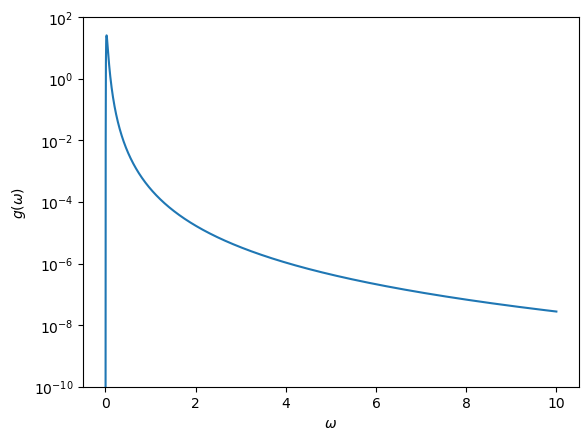

In [4]:
import matplotlib.pyplot as plt

# plot the spectrum g(omega) on a semilog scale
plt.semilogy(omegas, g_n(omegas))
plt.xlabel(r'$\omega$')
plt.ylabel(r'$g(\omega)$')
plt.ylim(1e-10, 100)
plt.show()

In [12]:
# solve for the frequency and damping rates for the normal mass ordering case

from scipy.optimize import root_scalar

print("Normal mass ordering:")
print("  Monopole mode:")
r = root_scalar(lambda x: 1 - chi00(x, g_n, a=0, b=np.inf), x0=0.01 - 0.3j, x1=0.02 - 0.4j)
Omega_n0, gamma_n0 = -r.root.imag, r.root.real 
print(f"  Omega_0 = {Omega_n0:.4f}, gamma_0 = {gamma_n0:.4e}, predicted gamma = {-np.pi * g_n(1):.4e}")

print("  Dipole mode:")
r = root_scalar(lambda x: 1 + (1/3) * chi00(x, g_n, a=0, b=np.inf), x0=0.01 + 1.3j, x1=0.02 + 1.4j)
Omega_ni, gamma_ni = -r.root.imag, r.root.real 
print(f"  Omega_i = {Omega_ni:.4f}, gamma_i = {gamma_ni:.4e}, predicted gamma = 0")

Normal mass ordering:
  Monopole mode:
  Omega_0 = 0.0475, gamma_0 = -6.8773e-04, predicted gamma = -8.2765e-04
  Dipole mode:
  Omega_i = -1.2909, gamma_i = -1.8273e-13, predicted gamma = 0


In [13]:
# solve for the frequency and damping rates for the inverted mass ordering case

print("Inverted mass ordering:")
print("  Monopole mode:")
r = root_scalar(lambda x: 1 - chi00(x, g_i, a=-np.inf, b=0), x0=0.01 - 0.3j, x1=0.02 - 0.4j)
Omega_i0, gamma_i0 = -r.root.imag, r.root.real 
print(f"  Omega_0 = {Omega_i0:.4f}, gamma_0 = {gamma_i0:.4e}, predicted gamma = 0")

print("  Dipole mode:")
r = root_scalar(lambda x: 1 + (1/3) * chi00(x, g_i, a=-np.inf, b=0), x0=0.01 + 1.3j, x1=0.02 + 1.4j)
Omega_ii, gamma_ii = -r.root.imag, r.root.real 
print(f"  Omega_i = {Omega_ii:.4f}, gamma_i = {gamma_ii:.4e}, predicted gamma = {-np.pi/9 * g_i(-1/3):.4e}")

Inverted mass ordering:
  Monopole mode:
  Omega_0 = -0.0443, gamma_0 = 1.7037e-10, predicted gamma = 0
  Dipole mode:
  Omega_i = -1.3833, gamma_i = -3.8843e-03, predicted gamma = -6.6732e-03


Let's run the simulation using the `f2i` (2-flavor, isotropic) model with the initial polarization vectors

$$ \mathbf{P}_\omega(0) = g(\omega) \times [0.01, 0, 1]^T. $$

In [14]:
from nugas.f2i import NuGas

# create the nugas model for the normal mass ordering case
eta = 0.01 # small perturbation parameter
P_ini = np.array([eta, 0, 1]) * g_n(omegas)[:, None] # initial polarization vector, with small transverse component
gas_n = NuGas(omegas=omegas, P_ini=P_ini, weights=weights, theta=0)

# run the simulation
Nt = 101 # number of time steps
tf = 50 # final time
gas_n.evolve(np.linspace(0, tf, Nt)[1:]);

In [15]:
# create the nugas model for the inverted mass ordering
P_ini = np.array([eta, 0, 1]) * g_i(-omegas)[:, None] # initial polarization vector, with small transverse component
gas_i = NuGas(omegas=-omegas, P_ini=P_ini, weights=weights, theta=0)

# run the simulation
gas_i.evolve(np.linspace(0, tf, Nt)[1:]);

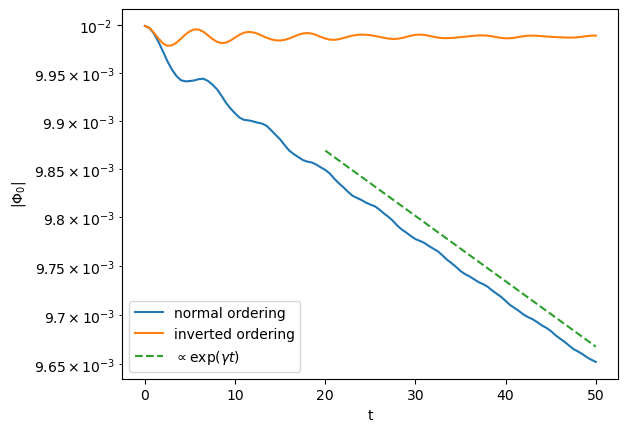

In [16]:
# monopole moment of the flavor coherence distribution
Phi0_n = np.sum((gas_n.P[:,:,0] + 1j * gas_n.P[:,:,1]) * weights, axis=1)
Phi0_i = np.sum((gas_i.P[:,:,0] + 1j * gas_i.P[:,:,1]) * weights, axis=1)
t0i = 40 # index of the time step to show the exponential decay

# Demonstrate the Landau damping
plt.semilogy(gas_n.t, np.abs(Phi0_n), label='normal ordering')
plt.semilogy(gas_i.t, np.abs(Phi0_i), label='inverted ordering')
plt.semilogy(gas_n.t[t0i:], (np.abs(Phi0_n[t0i]) + 2e-5 ) * np.exp(gamma_n0 * (gas_n.t[t0i:] - gas_n.t[t0i])), "--", label=r"$\propto\exp(\gamma t)$") # plot the expected exponential growth based on the linear stability analysis

plt.xlabel('t')
plt.ylabel(r'$|\Phi_0|$')
plt.legend()
plt.show()

## Acknowledgements

This material is based upon work supported by the U.S. Department of Energy, Office of Science, Office of Nuclear Physics under Award Number DE-SC-0017803.